<a href="https://colab.research.google.com/github/valinarp/TidalStudy/blob/main/Width%20of%20Channel%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install rasterio scikit-image opencv-python scipy

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List all files in your Drive to find the correct path
print("Files in your Drive:")
for root, dirs, files in os.walk('/content/drive/My Drive'):
    for file in files:
        if file.endswith(('.tif', '.tiff')):
            full_path = os.path.join(root, file)
            print(full_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in your Drive:
/content/drive/My Drive/Classroom/SIG 2022 Jumat 11 - 13/12019012_Valina Rizky P_AreaKerja.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-32_v1.0.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-31_v1.0.tif
/content/drive/My Drive/es2/Papua.tif
/content/drive/My Drive/es2/papua_skel.tif
/content/drive/My Drive/es2/Flyyy.tif
/content/drive/My Drive/es2/contoh.tif


Map shape: (605, 870)
Unique values: [0. 1.]
Water pixels: 132417


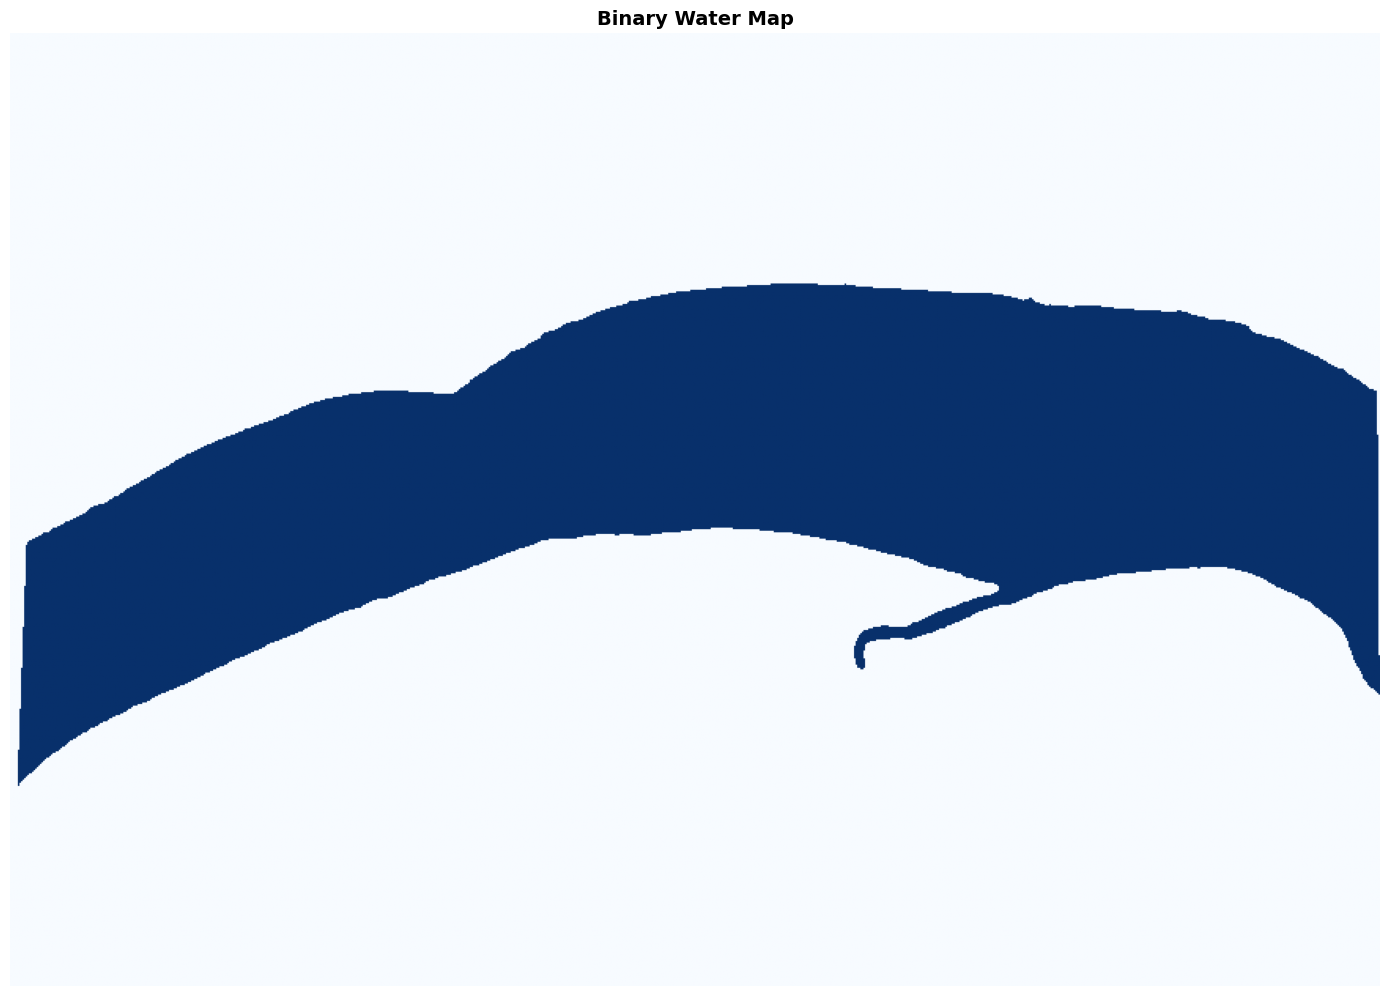

In [37]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import cv2

# Load binary TIF file
def load_binary_map(filepath):
    """Load binary TIF file (water=1, non-water=0)"""
    with rasterio.open(filepath) as src:
        data = src.read(1)
        geotransform = src.transform
    return data, geotransform

# Load your data
binary_map, geotransform = load_binary_map('/content/drive/My Drive/es2/contoh.tif')

print(f"Map shape: {binary_map.shape}")
print(f"Unique values: {np.unique(binary_map)}")
print(f"Water pixels: {np.sum(binary_map > 0)}")

# Visualize
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
axes.imshow(binary_map, cmap='Blues')
axes.set_title('Binary Water Map', fontweight='bold', fontsize=14)
axes.axis('off')
plt.tight_layout()
plt.show()


STEP 1: EXTRACTING SKELETON
✓ Skeleton extracted!
Skeleton pixels: 1205


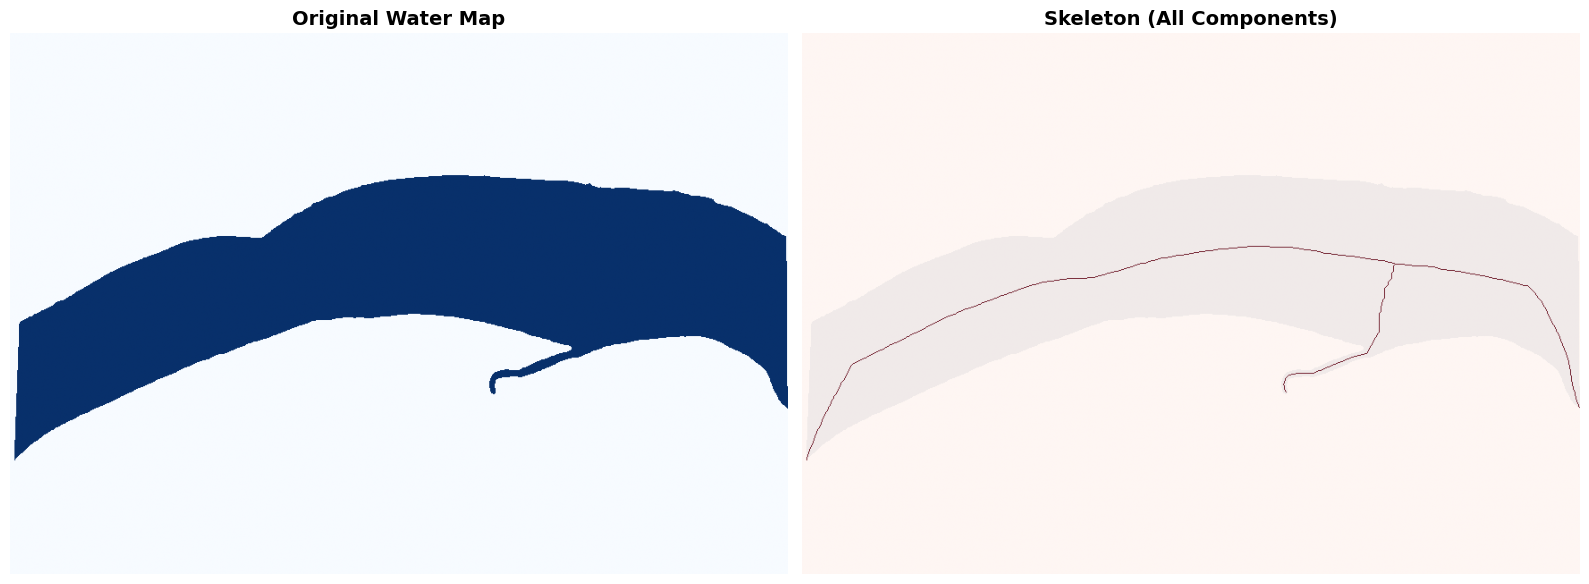

In [38]:
print("\n" + "="*70)
print("STEP 1: EXTRACTING SKELETON")
print("="*70)

def extract_skeleton(binary_map):
    """Extract skeleton/centerline using morphological thinning."""
    skeleton = morphology.skeletonize(binary_map)
    return skeleton

skeleton = extract_skeleton(binary_map)
print(f"✓ Skeleton extracted!")
print(f"Skeleton pixels: {np.sum(skeleton > 0)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(binary_map, cmap='Blues')
axes[0].set_title('Original Water Map', fontweight='bold', fontsize=14)
axes[0].axis('off')

axes[1].imshow(binary_map, cmap='Blues', alpha=0.3)
axes[1].imshow(skeleton, cmap='Reds', alpha=0.8)
axes[1].set_title('Skeleton (All Components)', fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [39]:
print("\n" + "="*70)
print("STEP 2: FINDING LONGEST CONTINUOUS PATH")
print("="*70)

def find_endpoints(skeleton):
    """Find endpoints of skeleton (pixels with only 1 neighbor)."""
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)

    neighbors = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel)
    endpoints = np.argwhere((neighbors == 1) & (skeleton == 1))

    return endpoints

def trace_path_from_point(skeleton, start_y, start_x, max_length=100000):
    """
    Trace a continuous path from a starting point.
    Returns the path as a list of (y, x) coordinates.
    """
    path = [(start_y, start_x)]
    visited = {(start_y, start_x)}
    current_y, current_x = start_y, start_x

    while len(path) < max_length:
        # Find neighbors
        neighbors = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                ny, nx = current_y + dy, current_x + dx

                if (0 <= ny < skeleton.shape[0] and
                    0 <= nx < skeleton.shape[1] and
                    skeleton[ny, nx] == 1 and
                    (ny, nx) not in visited):
                    neighbors.append((ny, nx))

        if not neighbors:
            break

        # Choose neighbor (prefer continuing straight)
        if len(neighbors) == 1:
            current_y, current_x = neighbors[0]
        else:
            # If multiple neighbors, choose the one most aligned with previous direction
            if len(path) > 1:
                prev_dy = path[-1][0] - path[-2][0]
                prev_dx = path[-1][1] - path[-2][1]

                best_neighbor = neighbors[0]
                best_score = float('-inf')

                for ny, nx in neighbors:
                    dy = ny - current_y
                    dx = nx - current_x
                    # Dot product (prefer same direction)
                    score = dy * prev_dy + dx * prev_dx
                    if score > best_score:
                        best_score = score
                        best_neighbor = (ny, nx)

                current_y, current_x = best_neighbor
            else:
                current_y, current_x = neighbors[0]

        path.append((current_y, current_x))
        visited.add((current_y, current_x))

    return path

def find_longest_path_in_skeleton(skeleton):
    """
    Find the longest continuous path in the skeleton.
    """
    endpoints = find_endpoints(skeleton)

    print(f"Found {len(endpoints)} endpoints")

    longest_path = []
    longest_length = 0

    # Try starting from each endpoint
    for endpoint_y, endpoint_x in endpoints:
        path = trace_path_from_point(skeleton, endpoint_y, endpoint_x)

        if len(path) > longest_length:
            longest_length = len(path)
            longest_path = path

    return longest_path, longest_length

# Find longest path
longest_path, path_length = find_longest_path_in_skeleton(skeleton)

print(f"✓ Found longest continuous path!")
print(f"Path length: {path_length} pixels")

# Convert path to arrays
path_array = np.array(longest_path)
y_coords = path_array[:, 0]
x_coords = path_array[:, 1]

print(f"X range: {x_coords.min():.0f} - {x_coords.max():.0f}")
print(f"Y range: {y_coords.min():.0f} - {y_coords.max():.0f}")


STEP 2: FINDING LONGEST CONTINUOUS PATH
Found 2 endpoints
✓ Found longest continuous path!
Path length: 999 pixels
X range: 5 - 869
Y range: 238 - 477


In [42]:
print("\n" + "="*70)
print("STEP 2: FINDING LONGEST CONTINUOUS PATH")
print("="*70)

def find_endpoints(skeleton):
    """Find endpoints of skeleton (pixels with only 1 neighbor)."""
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)

    neighbors = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel)
    endpoints = np.argwhere((neighbors == 1) & (skeleton == 1))

    return endpoints

def trace_path_from_point(skeleton, start_y, start_x, max_length=100000):
    """
    Trace a continuous path from a starting point.
    Returns the path as a list of (y, x) coordinates.
    """
    path = [(start_y, start_x)]
    visited = {(start_y, start_x)}
    current_y, current_x = start_y, start_x

    while len(path) < max_length:
        # Find neighbors
        neighbors = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                ny, nx = current_y + dy, current_x + dx

                if (0 <= ny < skeleton.shape[0] and
                    0 <= nx < skeleton.shape[1] and
                    skeleton[ny, nx] == 1 and
                    (ny, nx) not in visited):
                    neighbors.append((ny, nx))

        if not neighbors:
            break

        # Choose neighbor (prefer continuing straight)
        if len(neighbors) == 1:
            current_y, current_x = neighbors[0]
        else:
            # If multiple neighbors, choose the one most aligned with previous direction
            if len(path) > 1:
                prev_dy = path[-1][0] - path[-2][0]
                prev_dx = path[-1][1] - path[-2][1]

                best_neighbor = neighbors[0]
                best_score = float('-inf')

                for ny, nx in neighbors:
                    dy = ny - current_y
                    dx = nx - current_x
                    # Dot product (prefer same direction)
                    score = dy * prev_dy + dx * prev_dx
                    if score > best_score:
                        best_score = score
                        best_neighbor = (ny, nx)

                current_y, current_x = best_neighbor
            else:
                current_y, current_x = neighbors[0]

        path.append((current_y, current_x))
        visited.add((current_y, current_x))

    return path

def find_longest_path_in_skeleton(skeleton):
    """
    Find the longest continuous path in the skeleton.
    """
    endpoints = find_endpoints(skeleton)

    print(f"Found {len(endpoints)} endpoints")

    longest_path = []
    longest_length = 0

    # Try starting from each endpoint
    for endpoint_y, endpoint_x in endpoints:
        path = trace_path_from_point(skeleton, endpoint_y, endpoint_x)

        if len(path) > longest_length:
            longest_length = len(path)
            longest_path = path

    return longest_path, longest_length

# Find longest path
longest_path, path_length = find_longest_path_in_skeleton(skeleton)

print(f"✓ Found longest continuous path!")
print(f"Path length: {path_length} pixels")

# Convert path to arrays
path_array = np.array(longest_path)
y_coords = path_array[:, 0]
x_coords = path_array[:, 1]

print(f"X range: {x_coords.min():.0f} - {x_coords.max():.0f}")
print(f"Y range: {y_coords.min():.0f} - {y_coords.max():.0f}")


STEP 2: FINDING LONGEST CONTINUOUS PATH
Found 2 endpoints
✓ Found longest continuous path!
Path length: 999 pixels
X range: 5 - 869
Y range: 238 - 477


In [43]:
print("\n" + "="*70)
print("STEP 3: SMOOTHING CENTERLINE")
print("="*70)

def smooth_path(path, window_size=5):
    """Smooth the path using moving average."""
    if len(path) < window_size:
        return path

    path_array = np.array(path, dtype=np.float32)
    smoothed = np.zeros_like(path_array)

    for i in range(len(path)):
        start = max(0, i - window_size // 2)
        end = min(len(path), i + window_size // 2 + 1)
        smoothed[i] = np.mean(path_array[start:end], axis=0)

    return smoothed.astype(np.int32)

# Smooth the centerline
smoothed_path = smooth_path(longest_path, window_size=7)
y_smooth = smoothed_path[:, 0]
x_smooth = smoothed_path[:, 1]

print(f"✓ Centerline smoothed!")
print(f"Smoothed centerline points: {len(x_smooth)}")


STEP 3: SMOOTHING CENTERLINE
✓ Centerline smoothed!
Smoothed centerline points: 999


In [44]:
print("\n" + "="*70)
print("STEP 5: PRUNING CENTERLINE")
print("="*70)

def prune_centerline(x_coords, y_coords, min_distance=10):
    """
    Remove small branches by keeping only main path.
    Uses distance-based filtering.
    """

    pruned_x = [x_coords[0]]
    pruned_y = [y_coords[0]]

    for i in range(1, len(x_coords)):
        # Calculate distance from last kept point
        dist_from_last = np.sqrt(
            (x_coords[i] - pruned_x[-1])**2 +
            (y_coords[i] - pruned_y[-1])**2
        )

        if dist_from_last >= min_distance:
            pruned_x.append(x_coords[i])
            pruned_y.append(y_coords[i])

    return np.array(pruned_x), np.array(pruned_y)

# Prune centerline
x_pruned, y_pruned = prune_centerline(x_smooth, y_smooth, min_distance=5)

print(f"✓ Pruned! Original: {len(x_smooth)} points → {len(x_pruned)} points")
print(f"Removed: {len(x_smooth) - len(x_pruned)} points")


STEP 5: PRUNING CENTERLINE
✓ Pruned! Original: 999 points → 201 points
Removed: 798 points



STEP 4: VISUALIZING CENTERLINE


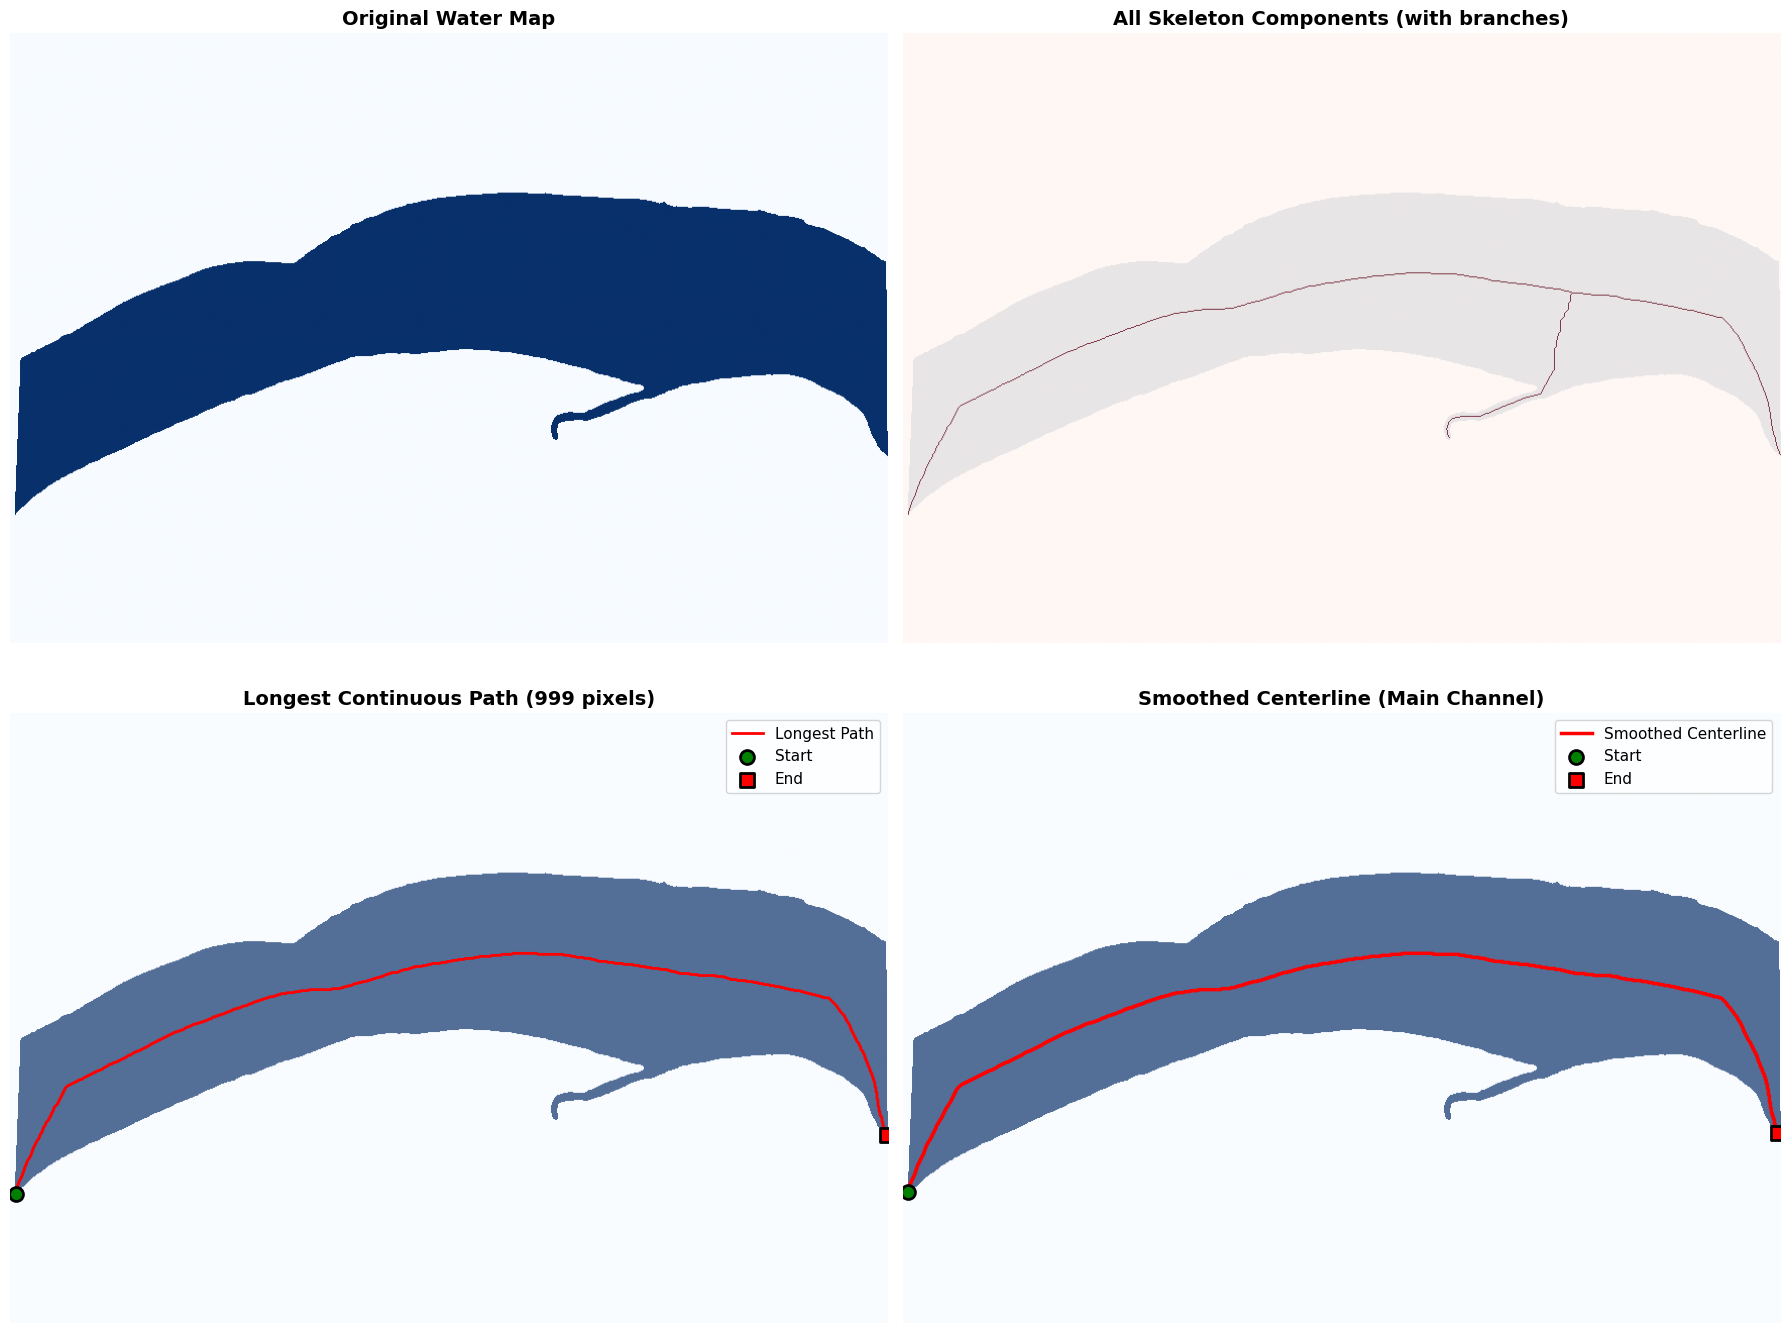

In [46]:
print("\n" + "="*70)
print("STEP 4: VISUALIZING CENTERLINE")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Original water map
axes[0, 0].imshow(binary_map, cmap='Blues')
axes[0, 0].set_title('Original Water Map', fontweight='bold', fontsize=14)
axes[0, 0].axis('off')

# Plot 2: All skeleton
axes[0, 1].imshow(binary_map, cmap='Blues', alpha=0.3)
axes[0, 1].imshow(skeleton, cmap='Reds', alpha=0.7)
axes[0, 1].set_title('All Skeleton Components (with branches)',
                     fontweight='bold', fontsize=14)
axes[0, 1].axis('off')

# Plot 3: Longest path (unsmoothed)
axes[1, 0].imshow(binary_map, cmap='Blues', alpha=0.7)
axes[1, 0].plot(x_coords, y_coords, 'r-', linewidth=2, label='Longest Path')
axes[1, 0].scatter(x_coords[0], y_coords[0], c='green', s=100, marker='o',
                  label='Start', zorder=5, edgecolors='black', linewidth=2)
axes[1, 0].scatter(x_coords[-1], y_coords[-1], c='red', s=100, marker='s',
                  label='End', zorder=5, edgecolors='black', linewidth=2)
axes[1, 0].set_title(f'Longest Continuous Path ({path_length} pixels)',
                     fontweight='bold', fontsize=14)
axes[1, 0].axis('off')
axes[1, 0].legend(fontsize=11, loc='upper right')

# Plot 4: Smoothed centerline
axes[1, 1].imshow(binary_map, cmap='Blues', alpha=0.7)
axes[1, 1].plot(x_smooth, y_smooth, 'r-', linewidth=2.5, label='Smoothed Centerline')
axes[1, 1].scatter(x_smooth[0], y_smooth[0], c='green', s=100, marker='o',
                  label='Start', zorder=5, edgecolors='black', linewidth=2)
axes[1, 1].scatter(x_smooth[-1], y_smooth[-1], c='red', s=100, marker='s',
                  label='End', zorder=5, edgecolors='black', linewidth=2)
axes[1, 1].set_title('Smoothed Centerline (Main Channel)',
                     fontweight='bold', fontsize=14)
axes[1, 1].axis('off')
axes[1, 1].legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [47]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import geopandas as gpd
from shapely.geometry import LineString, Polygon, box
import pandas as pd
import cv2

# Load binary map
def load_binary_map(filepath):
    """Load binary TIF file (water=1, non-water=0)"""
    with rasterio.open(filepath) as src:
        data = src.read(1)
        geotransform = src.transform
    return data, geotransform

binary_map, geotransform = load_binary_map('/content/drive/My Drive/es2/contoh.tif')

# Load centerline (from previous step)
# Assuming you have x_pruned and y_pruned from centerline generation
# If not, generate them first using the previous code

print(f"Binary map shape: {binary_map.shape}")
print(f"Water pixels: {np.sum(binary_map > 0)}")

Binary map shape: (605, 870)
Water pixels: 132417



STEP 1: ADVANCED BRANCH PRUNING
Pruning branches from centerline...
Found 0 potential branch points
✓ Pruned! Original: 201 points → 201 points
Removed: 0 points


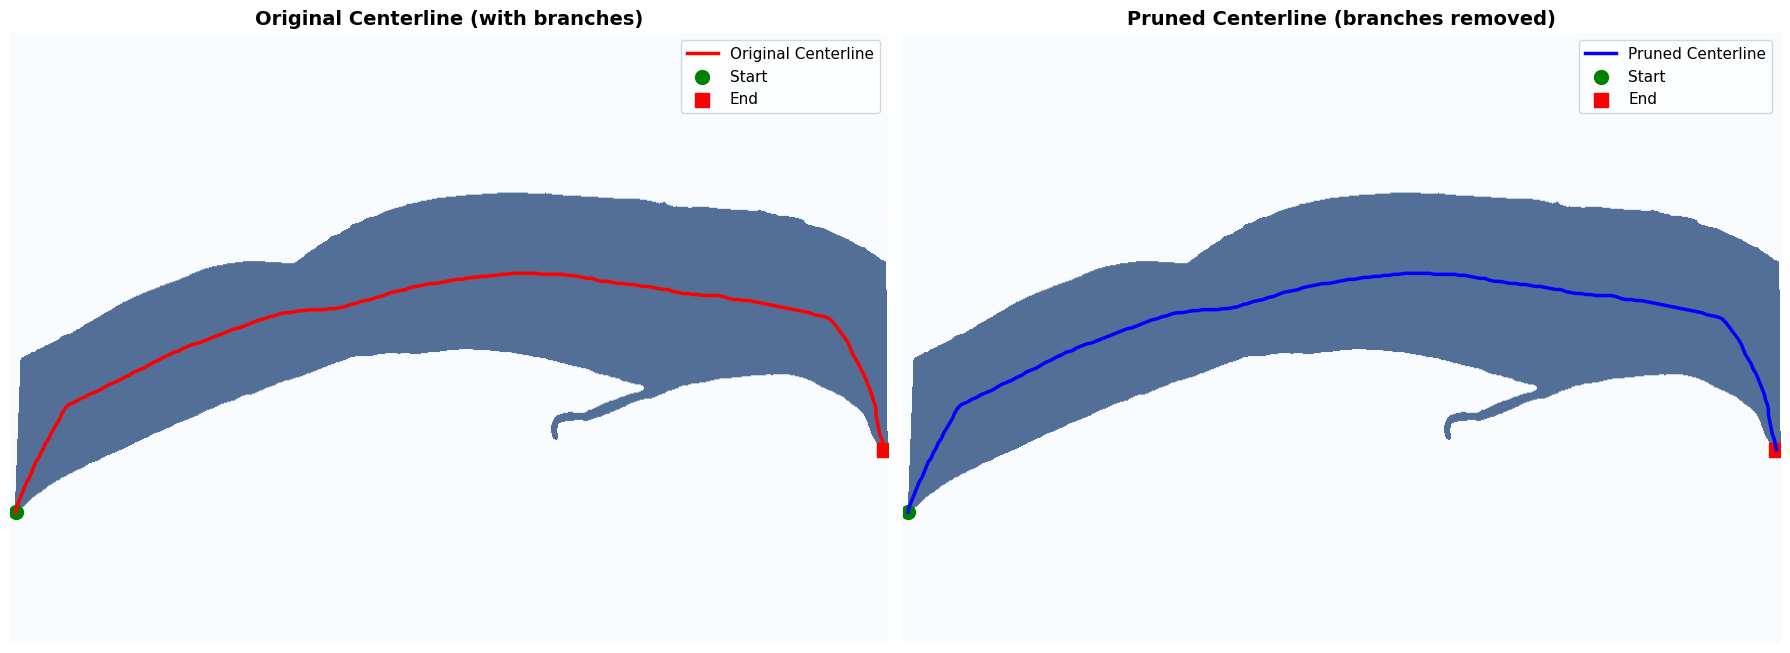

In [48]:
print("\n" + "="*70)
print("STEP 1: ADVANCED BRANCH PRUNING")
print("="*70)

def identify_and_remove_branches(x_coords, y_coords, min_branch_length=20):
    """
    Identify and remove branches from centerline.
    Branches are detected as deviations from main path.

    Args:
        x_coords: X coordinates of centerline
        y_coords: Y coordinates of centerline
        min_branch_length: Minimum length to keep branch (pixels)

    Returns:
        Pruned x and y coordinates
    """

    # Calculate curvature at each point
    curvatures = []

    for i in range(1, len(x_coords) - 1):
        # Calculate angle change (curvature)
        dx1 = x_coords[i] - x_coords[i-1]
        dy1 = y_coords[i] - y_coords[i-1]
        dx2 = x_coords[i+1] - x_coords[i]
        dy2 = y_coords[i+1] - y_coords[i]

        # Angle between vectors
        dot_product = dx1*dx2 + dy1*dy2
        mag1 = np.sqrt(dx1**2 + dy1**2)
        mag2 = np.sqrt(dx2**2 + dy2**2)

        if mag1 > 0 and mag2 > 0:
            cos_angle = dot_product / (mag1 * mag2)
            curvature = np.arccos(np.clip(cos_angle, -1, 1))
        else:
            curvature = 0

        curvatures.append(curvature)

    # Find sharp turns (potential branch points)
    curvature_threshold = np.pi / 4  # 45 degrees
    branch_points = []

    for i in range(len(curvatures)):
        if curvatures[i] > curvature_threshold:
            branch_points.append(i + 1)

    print(f"Found {len(branch_points)} potential branch points")

    # Keep only main path (remove branches)
    pruned_x = [x_coords[0]]
    pruned_y = [y_coords[0]]

    for i in range(1, len(x_coords)):
        # Check if this point is part of main path
        # Keep if not near a branch point or if continuing main direction

        if i not in branch_points:
            pruned_x.append(x_coords[i])
            pruned_y.append(y_coords[i])
        else:
            # At branch point, decide which direction to follow
            # Continue in the direction of main flow
            if i > 0:
                dx_prev = x_coords[i] - x_coords[i-1]
                dy_prev = y_coords[i] - y_coords[i-1]

                if i < len(x_coords) - 1:
                    dx_next = x_coords[i+1] - x_coords[i]
                    dy_next = y_coords[i+1] - y_coords[i]

                    # Dot product (prefer continuing straight)
                    dot = dx_prev*dx_next + dy_prev*dy_next

                    if dot > 0:  # Continuing in similar direction
                        pruned_x.append(x_coords[i])
                        pruned_y.append(y_coords[i])

    return np.array(pruned_x), np.array(pruned_y)

# Prune branches
print("Pruning branches from centerline...")
x_pruned_advanced, y_pruned_advanced = identify_and_remove_branches(
    x_pruned, y_pruned, min_branch_length=20
)

print(f"✓ Pruned! Original: {len(x_pruned)} points → {len(x_pruned_advanced)} points")
print(f"Removed: {len(x_pruned) - len(x_pruned_advanced)} points")

# Visualize before and after pruning
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(binary_map, cmap='Blues', alpha=0.7)
axes[0].plot(x_pruned, y_pruned, 'r-', linewidth=2.5, label='Original Centerline')
axes[0].scatter(x_pruned[0], y_pruned[0], c='green', s=100, marker='o', label='Start')
axes[0].scatter(x_pruned[-1], y_pruned[-1], c='red', s=100, marker='s', label='End')
axes[0].set_title('Original Centerline (with branches)', fontweight='bold', fontsize=14)
axes[0].axis('off')
axes[0].legend(fontsize=11)

axes[1].imshow(binary_map, cmap='Blues', alpha=0.7)
axes[1].plot(x_pruned_advanced, y_pruned_advanced, 'b-', linewidth=2.5, label='Pruned Centerline')
axes[1].scatter(x_pruned_advanced[0], y_pruned_advanced[0], c='green', s=100, marker='o', label='Start')
axes[1].scatter(x_pruned_advanced[-1], y_pruned_advanced[-1], c='red', s=100, marker='s', label='End')
axes[1].set_title('Pruned Centerline (branches removed)', fontweight='bold', fontsize=14)
axes[1].axis('off')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [49]:
print("\n" + "="*70)
print("STEP 2: CREATING PERPENDICULAR POLYGONS")
print("="*70)

def create_perpendicular_polygons(x_coords, y_coords, polygon_width=50, spacing=10):
    """
    Create perpendicular polygons along centerline.
    Each polygon crosses the centerline perpendicularly.

    Args:
        x_coords: X coordinates of centerline
        y_coords: Y coordinates of centerline
        polygon_width: Width of each polygon perpendicular to centerline (pixels)
        spacing: Distance between polygon centers along centerline (pixels)

    Returns:
        List of Polygon geometries and metadata
    """

    polygons = []
    polygon_data = []

    print(f"Creating polygons with width={polygon_width}, spacing={spacing}")

    # Create polygons at regular intervals
    for i in range(0, len(x_coords) - 1, spacing):
        current_x = x_coords[i]
        current_y = y_coords[i]

        # Calculate tangent direction (along centerline)
        if i == 0:
            dx = x_coords[i+1] - x_coords[i]
            dy = y_coords[i+1] - y_coords[i]
        elif i >= len(x_coords) - 1:
            dx = x_coords[i] - x_coords[i-1]
            dy = y_coords[i] - y_coords[i-1]
        else:
            # Use central difference for better direction
            dx = x_coords[i+1] - x_coords[i-1]
            dy = y_coords[i+1] - y_coords[i-1]

        # Normalize tangent direction
        tangent_length = np.sqrt(dx**2 + dy**2)
        if tangent_length > 0:
            dx /= tangent_length
            dy /= tangent_length
        else:
            continue

        # Perpendicular direction (rotate 90 degrees counterclockwise)
        perp_dx = -dy
        perp_dy = dx

        # Create rectangle perpendicular to centerline
        # The rectangle extends along the centerline and perpendicular to it
        half_width = polygon_width / 2
        segment_length = spacing * 1.5  # Length along centerline

        # Four corners of the rectangle
        # Top-left corner
        p1_x = current_x - dx * segment_length/2 - perp_dx * half_width
        p1_y = current_y - dy * segment_length/2 - perp_dy * half_width

        # Top-right corner
        p2_x = current_x - dx * segment_length/2 + perp_dx * half_width
        p2_y = current_y - dy * segment_length/2 + perp_dy * half_width

        # Bottom-right corner
        p3_x = current_x + dx * segment_length/2 + perp_dx * half_width
        p3_y = current_y + dy * segment_length/2 + perp_dy * half_width

        # Bottom-left corner
        p4_x = current_x + dx * segment_length/2 - perp_dx * half_width
        p4_y = current_y + dy * segment_length/2 - perp_dy * half_width

        # Create polygon
        polygon_coords = [
            (p1_x, p1_y),
            (p2_x, p2_y),
            (p3_x, p3_y),
            (p4_x, p4_y)
        ]

        polygon = Polygon(polygon_coords)
        polygons.append(polygon)

        polygon_data.append({
            'polygon_id': len(polygons),
            'centerline_index': i,
            'center_x': current_x,
            'center_y': current_y,
            'polygon_width': polygon_width,
            'tangent_dx': dx,
            'tangent_dy': dy,
            'perp_dx': perp_dx,
            'perp_dy': perp_dy,
            'geometry': polygon
        })

    return polygons, polygon_data

# Create perpendicular polygons
polygons, polygon_data = create_perpendicular_polygons(
    x_pruned_advanced, y_pruned_advanced,
    polygon_width=100,   # Width of each polygon (pixels)
    spacing=20          # Distance between polygons (pixels)
)

print(f"✓ Created {len(polygons)} perpendicular polygons!")

# Create GeoDataFrame
gdf_polygons = gpd.GeoDataFrame(polygon_data, crs='EPSG:4326')


STEP 2: CREATING PERPENDICULAR POLYGONS
Creating polygons with width=100, spacing=20
✓ Created 10 perpendicular polygons!



STEP 3: VISUALIZING PERPENDICULAR POLYGONS
Visualizing perpendicular polygons...


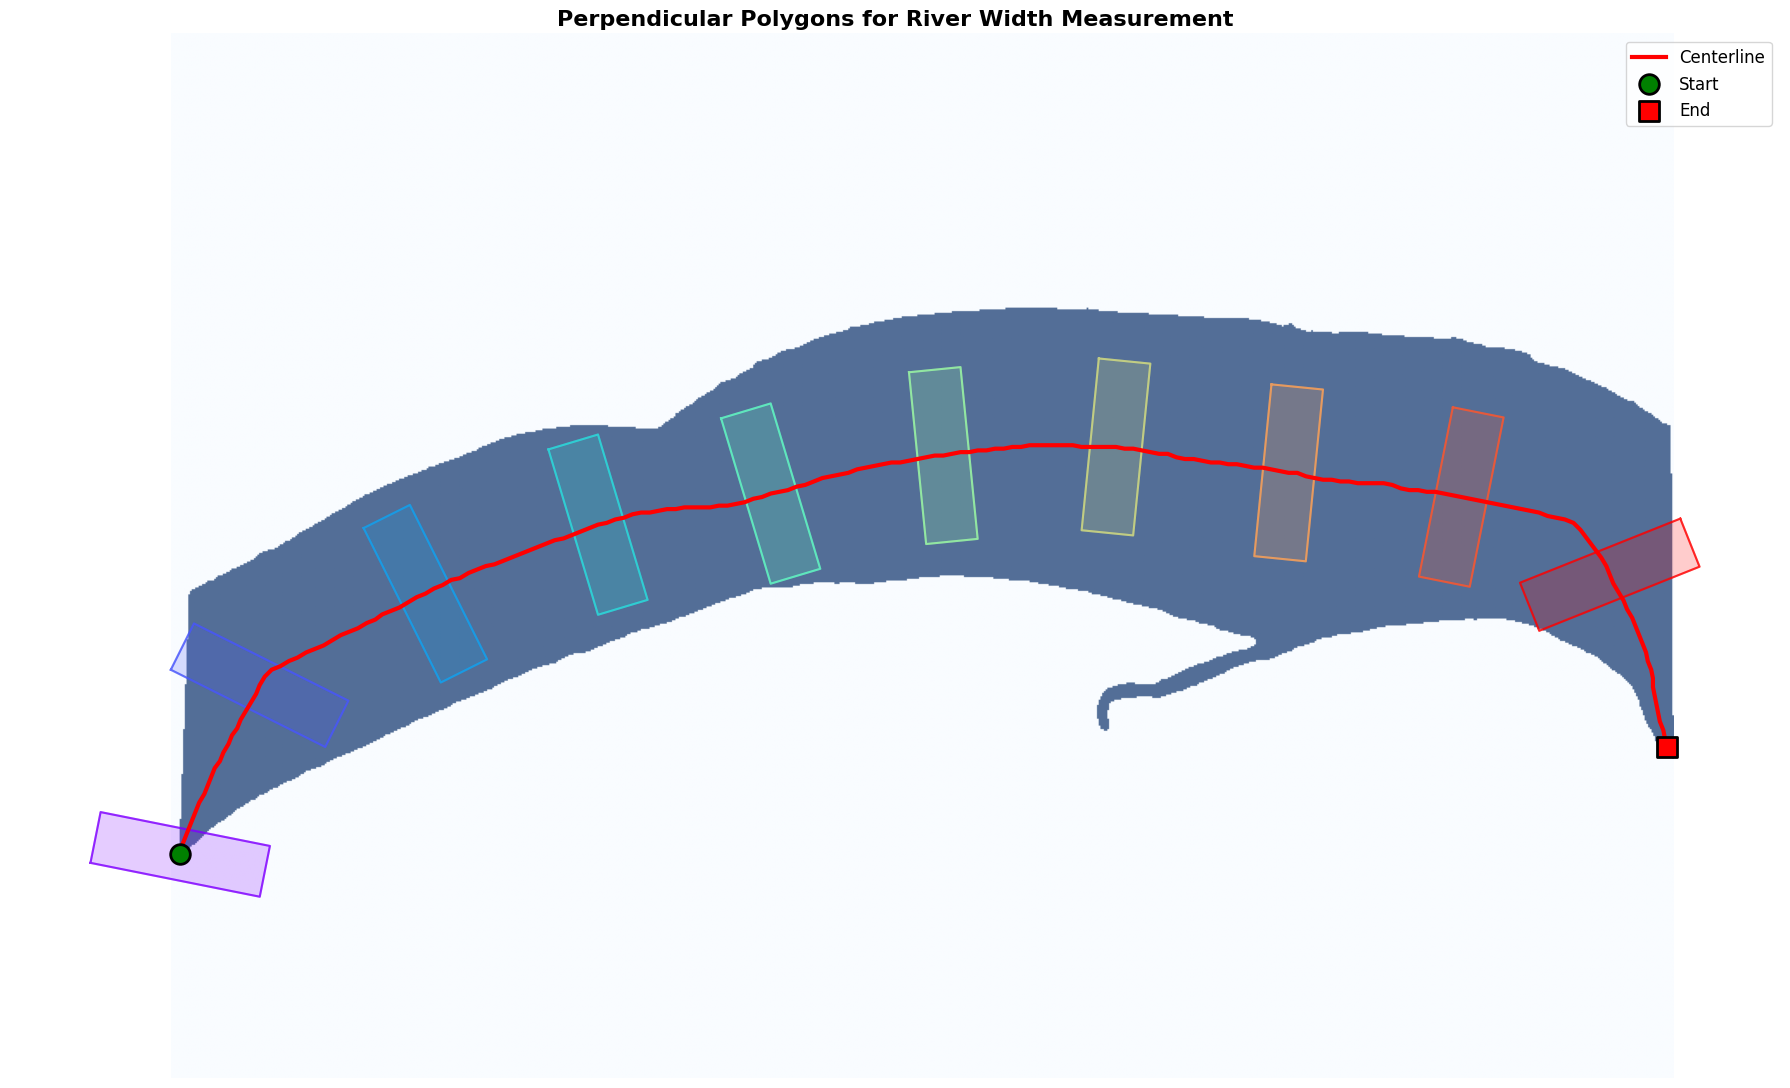

In [50]:
print("\n" + "="*70)
print("STEP 3: VISUALIZING PERPENDICULAR POLYGONS")
print("="*70)

def visualize_perpendicular_polygons(binary_map, x_centerline, y_centerline,
                                     polygons, title="Perpendicular Polygons"):
    """Visualize centerline with perpendicular polygons."""

    fig, ax = plt.subplots(figsize=(18, 12))

    # Plot water map
    ax.imshow(binary_map, cmap='Blues', alpha=0.7)

    # Plot centerline
    ax.plot(x_centerline, y_centerline, 'r-', linewidth=3, label='Centerline', zorder=3)

    # Plot polygons
    colors = plt.cm.rainbow(np.linspace(0, 1, len(polygons)))

    for idx, polygon in enumerate(polygons):
        x, y = polygon.exterior.xy
        ax.fill(x, y, color=colors[idx], alpha=0.2, edgecolor=colors[idx], linewidth=1.5)
        ax.plot(x, y, color=colors[idx], linewidth=1.5, alpha=0.8)

    # Plot start and end
    ax.scatter(x_centerline[0], y_centerline[0], c='green', s=200, marker='o',
              label='Start', zorder=5, edgecolors='black', linewidth=2)
    ax.scatter(x_centerline[-1], y_centerline[-1], c='red', s=200, marker='s',
              label='End', zorder=5, edgecolors='black', linewidth=2)

    ax.set_title(title, fontweight='bold', fontsize=16)
    ax.legend(fontsize=12, loc='upper right')
    ax.axis('off')
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

# Visualize
print("Visualizing perpendicular polygons...")
visualize_perpendicular_polygons(
    binary_map, x_pruned_advanced, y_pruned_advanced, polygons,
    title="Perpendicular Polygons for River Width Measurement"
)

In [51]:
print("\n" + "="*70)
print("STEP 4: CALCULATING RIVER WIDTH")
print("="*70)

def calculate_width_from_polygons(binary_map, polygons, polygon_data):
    """
    Calculate actual water width from each perpendicular polygon.

    Args:
        binary_map: Binary water map
        polygons: List of Polygon geometries
        polygon_data: List of polygon metadata

    Returns:
        DataFrame with width measurements
    """

    widths = []

    for idx, polygon in enumerate(polygons):
        # Get polygon bounds
        minx, miny, maxx, maxy = polygon.bounds

        # Extract pixels within polygon
        x_min, x_max = int(np.floor(minx)), int(np.ceil(maxx))
        y_min, y_max = int(np.floor(miny)), int(np.ceil(maxy))

        # Clip to raster bounds
        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(binary_map.shape[1], x_max)
        y_max = min(binary_map.shape[0], y_max)

        # Extract region
        if x_max > x_min and y_max > y_min:
            region = binary_map[y_min:y_max, x_min:x_max]

            # Count water pixels
            water_pixels = np.sum(region > 0)
            total_pixels = region.size

            # Calculate width
            polygon_width = polygon_data[idx]['polygon_width']

            # Width = (water pixels / total pixels) * polygon width
            if total_pixels > 0:
                width_fraction = water_pixels / total_pixels
                actual_width = width_fraction * polygon_width
            else:
                width_fraction = 0
                actual_width = 0
        else:
            water_pixels = 0
            total_pixels = 0
            width_fraction = 0
            actual_width = 0

        widths.append({
            'polygon_id': polygon_data[idx]['polygon_id'],
            'centerline_index': polygon_data[idx]['centerline_index'],
            'center_x': polygon_data[idx]['center_x'],
            'center_y': polygon_data[idx]['center_y'],
            'water_pixels': water_pixels,
            'total_pixels': total_pixels,
            'width_fraction': width_fraction,
            'actual_width_pixels': actual_width
        })

    return pd.DataFrame(widths)

# Calculate widths
print("Calculating river width from perpendicular polygons...")
df_widths = calculate_width_from_polygons(binary_map, polygons, polygon_data)

print("\n" + "="*80)
print("RIVER WIDTH MEASUREMENTS")
print("="*80)
print(df_widths.to_string())

print(f"\nStatistics:")
print(f"  Mean width: {df_widths['actual_width_pixels'].mean():.2f} pixels")
print(f"  Max width: {df_widths['actual_width_pixels'].max():.2f} pixels")
print(f"  Min width: {df_widths['actual_width_pixels'].min():.2f} pixels")
print(f"  Std dev: {df_widths['actual_width_pixels'].std():.2f} pixels")


STEP 4: CALCULATING RIVER WIDTH
Calculating river width from perpendicular polygons...

RIVER WIDTH MEASUREMENTS
   polygon_id  centerline_index  center_x  center_y  water_pixels  total_pixels  width_fraction  actual_width_pixels
0           1                 0         5       475           420          2850        0.147368            14.736842
1           2                20        51       377          6804          7416        0.917476            91.747573
2           3                40       147       324          7488          7488        1.000000           100.000000
3           4                60       247       284          6148          6148        1.000000           100.000000
4           5                80       347       266          6144          6148        0.999349            99.934938
5           6               100       447       244          4160          4160        1.000000           100.000000
6           7               120       547       239          4160  


STEP 5: WIDTH PROFILE ANALYSIS
Plotting width profile...


/tmp/ipykernel_540/3884927931.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


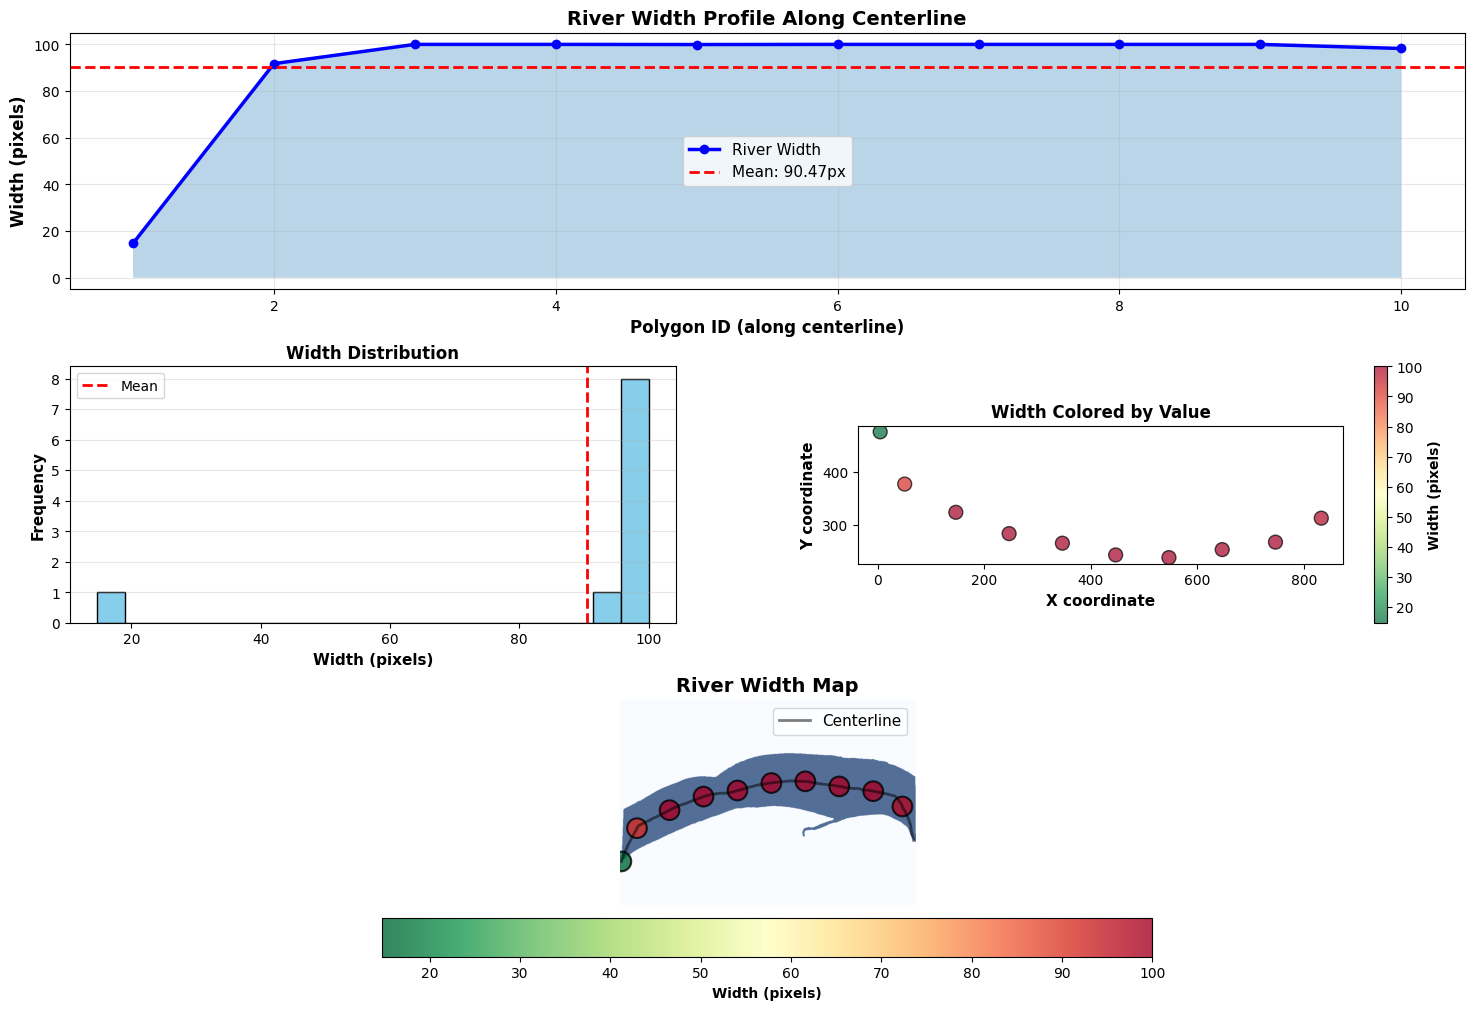

In [52]:
print("\n" + "="*70)
print("STEP 5: WIDTH PROFILE ANALYSIS")
print("="*70)

def plot_width_profile(df_widths, binary_map, x_centerline, y_centerline):
    """Plot width variation along centerline."""

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # Plot 1: Width profile
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_widths['polygon_id'], df_widths['actual_width_pixels'],
            'b-', linewidth=2.5, marker='o', markersize=6, label='River Width')
    ax1.fill_between(df_widths['polygon_id'], df_widths['actual_width_pixels'],
                    alpha=0.3)
    ax1.axhline(y=df_widths['actual_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2,
               label=f"Mean: {df_widths['actual_width_pixels'].mean():.2f}px")
    ax1.set_xlabel('Polygon ID (along centerline)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Width (pixels)', fontsize=12, fontweight='bold')
    ax1.set_title('River Width Profile Along Centerline', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    # Plot 2: Width distribution
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(df_widths['actual_width_pixels'], bins=20, edgecolor='black', color='skyblue')
    ax2.axvline(x=df_widths['actual_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2, label='Mean')
    ax2.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('Width Distribution', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Width vs position
    ax3 = fig.add_subplot(gs[1, 1])
    scatter = ax3.scatter(df_widths['center_x'], df_widths['center_y'],
                         c=df_widths['actual_width_pixels'], cmap='RdYlGn_r',
                         s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax3.set_xlabel('X coordinate', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Y coordinate', fontsize=11, fontweight='bold')
    ax3.set_title('Width Colored by Value', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Width (pixels)', fontsize=10, fontweight='bold')
    ax3.set_aspect('equal')

    # Plot 4: Map with width colors
    ax4 = fig.add_subplot(gs[2, :])
    ax4.imshow(binary_map, cmap='Blues', alpha=0.7)

    # Color points by width
    scatter2 = ax4.scatter(df_widths['center_x'], df_widths['center_y'],
                          c=df_widths['actual_width_pixels'], cmap='RdYlGn_r',
                          s=200, alpha=0.8, edgecolors='black', linewidth=1.5)
    ax4.plot(x_centerline, y_centerline, 'k-', linewidth=2, alpha=0.5, label='Centerline')
    ax4.set_title('River Width Map', fontsize=14, fontweight='bold')
    ax4.axis('off')
    ax4.legend(fontsize=11)
    cbar2 = plt.colorbar(scatter2, ax=ax4, orientation='horizontal', pad=0.05)
    cbar2.set_label('Width (pixels)', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Plot width profile
print("Plotting width profile...")
plot_width_profile(df_widths, binary_map, x_pruned_advanced, y_pruned_advanced)

In [53]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import geopandas as gpd
from shapely.geometry import LineString, Polygon
import pandas as pd
import cv2

# Load binary map
def load_binary_map(filepath):
    """Load binary TIF file (water=1, non-water=0)"""
    with rasterio.open(filepath) as src:
        data = src.read(1)
        geotransform = src.transform
    return data, geotransform

binary_map, geotransform = load_binary_map('/content/drive/My Drive/es2/contoh.tif')

print(f"Binary map shape: {binary_map.shape}")
print(f"Water pixels: {np.sum(binary_map > 0)}")

Binary map shape: (605, 870)
Water pixels: 132417


In [54]:
print("\n" + "="*70)
print("STEP 1: MEASURING EXACT WATER WIDTH AT EACH CENTERLINE POINT")
print("="*70)

def measure_width_perpendicular_to_centerline(binary_map, x_coords, y_coords,
                                               max_search_distance=200):
    """
    Measure the exact water width perpendicular to centerline at each point.
    Finds the actual water boundaries on both sides.

    Args:
        binary_map: Binary water map (water=1, non-water=0)
        x_coords: X coordinates of centerline
        y_coords: Y coordinates of centerline
        max_search_distance: Maximum distance to search for water boundary (pixels)

    Returns:
        DataFrame with width measurements
    """

    width_measurements = []

    print(f"Measuring width at {len(x_coords)} centerline points...")

    for i in range(len(x_coords)):
        current_x = x_coords[i]
        current_y = y_coords[i]

        # Calculate perpendicular direction
        if i == 0:
            # Use next point
            dx = x_coords[i+1] - x_coords[i]
            dy = y_coords[i+1] - y_coords[i]
        elif i == len(x_coords) - 1:
            # Use previous point
            dx = x_coords[i] - x_coords[i-1]
            dy = y_coords[i] - y_coords[i-1]
        else:
            # Use central difference
            dx = x_coords[i+1] - x_coords[i-1]
            dy = y_coords[i+1] - y_coords[i-1]

        # Normalize tangent direction
        tangent_length = np.sqrt(dx**2 + dy**2)
        if tangent_length > 0:
            dx /= tangent_length
            dy /= tangent_length
        else:
            continue

        # Perpendicular direction (rotate 90 degrees)
        perp_dx = -dy
        perp_dy = dx

        # Measure distance to water boundary in both perpendicular directions
        width_left = 0
        width_right = 0

        # Search LEFT direction (negative perpendicular)
        for dist in range(1, max_search_distance):
            check_x = int(current_x - perp_dx * dist)
            check_y = int(current_y - perp_dy * dist)

            # Check bounds
            if check_x < 0 or check_x >= binary_map.shape[1] or \
               check_y < 0 or check_y >= binary_map.shape[0]:
                break

            # Check if still in water
            if binary_map[check_y, check_x] > 0:
                width_left = dist
            else:
                # Found boundary
                break

        # Search RIGHT direction (positive perpendicular)
        for dist in range(1, max_search_distance):
            check_x = int(current_x + perp_dx * dist)
            check_y = int(current_y + perp_dy * dist)

            # Check bounds
            if check_x < 0 or check_x >= binary_map.shape[1] or \
               check_y < 0 or check_y >= binary_map.shape[0]:
                break

            # Check if still in water
            if binary_map[check_y, check_x] > 0:
                width_right = dist
            else:
                # Found boundary
                break

        # Total width
        total_width = width_left + width_right

        # Only record if we found water on both sides
        if total_width > 0:
            width_measurements.append({
                'point_id': i,
                'centerline_x': current_x,
                'centerline_y': current_y,
                'width_left_pixels': width_left,
                'width_right_pixels': width_right,
                'total_width_pixels': total_width,
                'tangent_dx': dx,
                'tangent_dy': dy,
                'perp_dx': perp_dx,
                'perp_dy': perp_dy
            })

    return pd.DataFrame(width_measurements)

# Measure widths
print("Measuring water width perpendicular to centerline...")
df_widths = measure_width_perpendicular_to_centerline(
    binary_map, x_pruned_advanced, y_pruned_advanced,
    max_search_distance=200
)

print(f"\n✓ Measured {len(df_widths)} width points!")
print(f"\nWidth Statistics:")
print(f"  Mean width: {df_widths['total_width_pixels'].mean():.2f} pixels")
print(f"  Max width: {df_widths['total_width_pixels'].max():.2f} pixels")
print(f"  Min width: {df_widths['total_width_pixels'].min():.2f} pixels")
print(f"  Std dev: {df_widths['total_width_pixels'].std():.2f} pixels")

print("\nFirst 10 measurements:")
print(df_widths.head(10).to_string())


STEP 1: MEASURING EXACT WATER WIDTH AT EACH CENTERLINE POINT
Measuring water width perpendicular to centerline...
Measuring width at 201 centerline points...

✓ Measured 201 width points!

Width Statistics:
  Mean width: 125.69 pixels
  Max width: 193.00 pixels
  Min width: 2.00 pixels
  Std dev: 46.32 pixels

First 10 measurements:
   point_id  centerline_x  centerline_y  width_left_pixels  width_right_pixels  total_width_pixels  tangent_dx  tangent_dy   perp_dx   perp_dy
0         0             5           475                  0                   2                   2    0.196116   -0.980581  0.980581  0.196116
1         1             6           470                  1                   5                   6    0.287348   -0.957826  0.957826  0.287348
2         2             8           465                  3                   8                  11    0.371391   -0.928477  0.928477  0.371391
3         3            10           460                  5                  10              

In [55]:
print("\n" + "="*70)
print("STEP 2: CREATING PERPENDICULAR WIDTH LINES")
print("="*70)

def create_perpendicular_width_lines(df_widths):
    """
    Create perpendicular line segments that represent actual water width.

    Args:
        df_widths: DataFrame with width measurements

    Returns:
        List of LineString geometries
    """

    lines = []
    line_data = []

    for idx, row in df_widths.iterrows():
        center_x = row['centerline_x']
        center_y = row['centerline_y']
        perp_dx = row['perp_dx']
        perp_dy = row['perp_dy']
        width_left = row['width_left_pixels']
        width_right = row['width_right_pixels']

        # Left boundary point
        left_x = center_x - perp_dx * width_left
        left_y = center_y - perp_dy * width_left

        # Right boundary point
        right_x = center_x + perp_dx * width_right
        right_y = center_y + perp_dy * width_right

        # Create line from left to right boundary
        line = LineString([(left_x, left_y), (right_x, right_y)])
        lines.append(line)

        line_data.append({
            'line_id': idx + 1,
            'point_id': row['point_id'],
            'center_x': center_x,
            'center_y': center_y,
            'left_x': left_x,
            'left_y': left_y,
            'right_x': right_x,
            'right_y': right_y,
            'width_pixels': row['total_width_pixels'],
            'geometry': line
        })

    return lines, line_data

# Create perpendicular lines
print("Creating perpendicular width lines...")
width_lines, width_line_data = create_perpendicular_width_lines(df_widths)

print(f"✓ Created {len(width_lines)} perpendicular width lines!")

# Create GeoDataFrame
gdf_width_lines = gpd.GeoDataFrame(width_line_data, crs='EPSG:4326')


STEP 2: CREATING PERPENDICULAR WIDTH LINES
Creating perpendicular width lines...
✓ Created 201 perpendicular width lines!



STEP 3: VISUALIZING PERPENDICULAR WIDTH LINES
Visualizing perpendicular width lines...


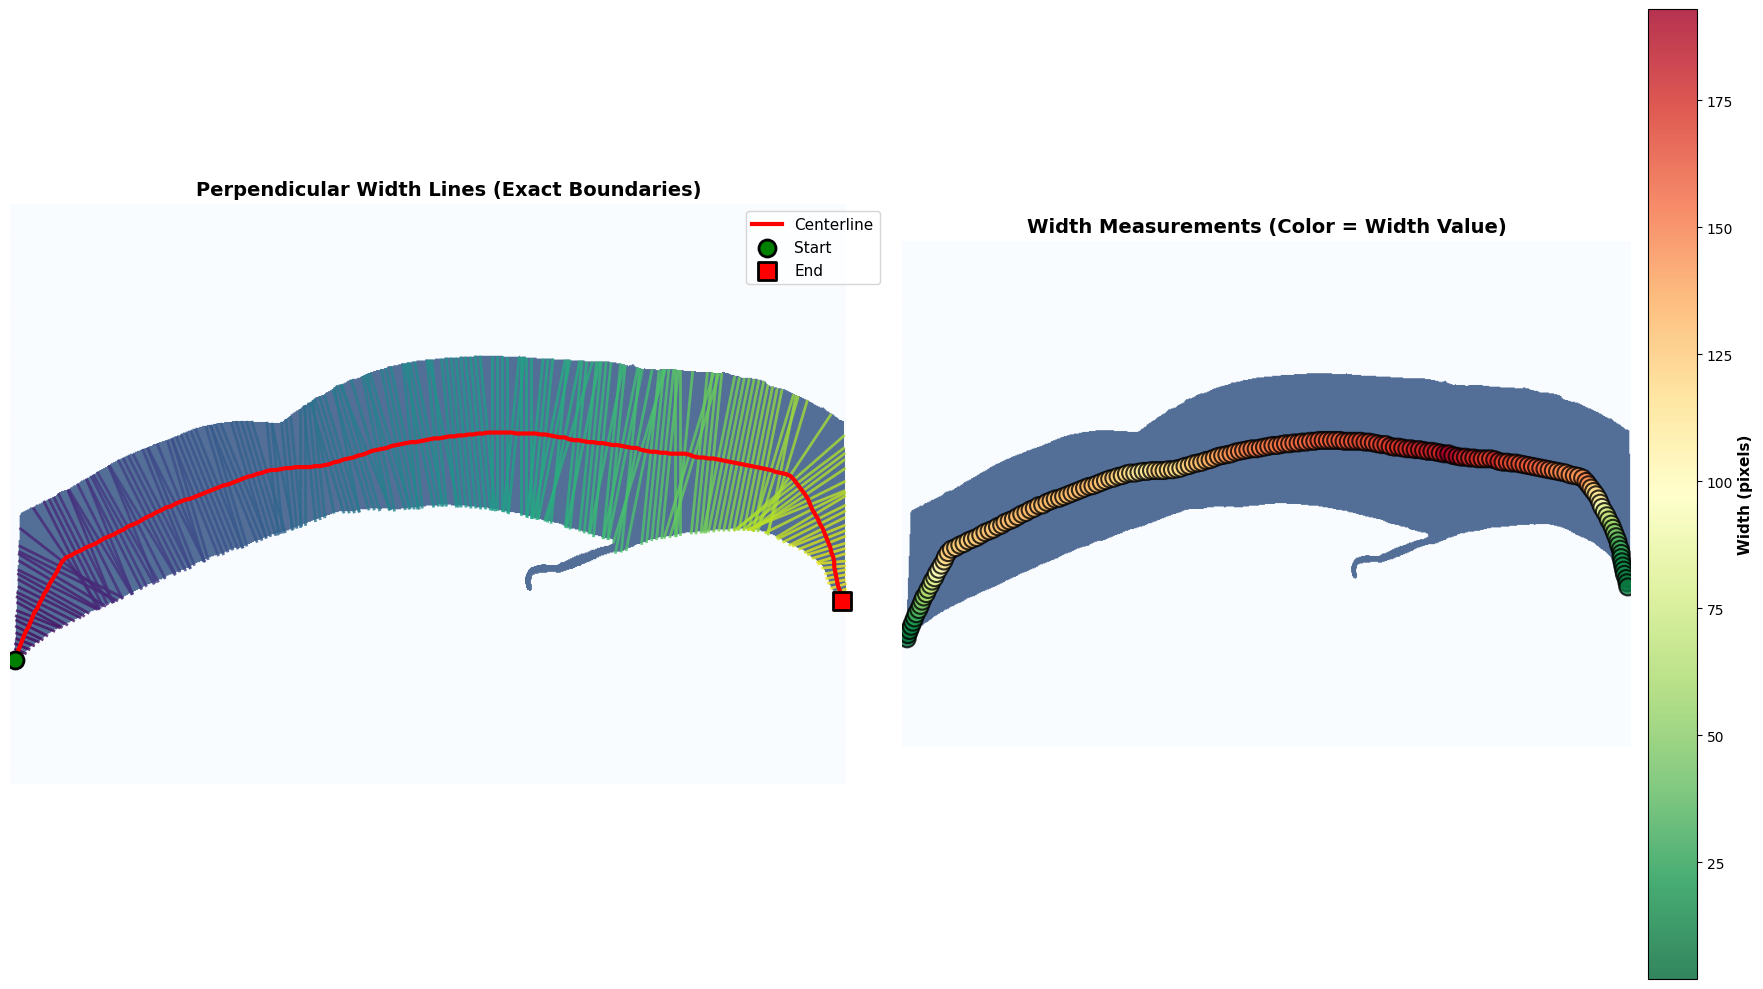

In [56]:
print("\n" + "="*70)
print("STEP 3: VISUALIZING PERPENDICULAR WIDTH LINES")
print("="*70)

def visualize_width_lines(binary_map, x_centerline, y_centerline,
                          df_widths, width_lines, title="Perpendicular Width Lines"):
    """Visualize centerline with perpendicular width lines."""

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Plot 1: All width lines
    axes[0].imshow(binary_map, cmap='Blues', alpha=0.7)

    # Plot centerline
    axes[0].plot(x_centerline, y_centerline, 'r-', linewidth=3,
                label='Centerline', zorder=3)

    # Plot width lines with color gradient
    colors = plt.cm.viridis(np.linspace(0, 1, len(width_lines)))

    for idx, line in enumerate(width_lines):
        x, y = line.xy
        axes[0].plot(x, y, color=colors[idx], linewidth=2, alpha=0.8)

    axes[0].scatter(x_centerline[0], y_centerline[0], c='green', s=150, marker='o',
                   label='Start', zorder=5, edgecolors='black', linewidth=2)
    axes[0].scatter(x_centerline[-1], y_centerline[-1], c='red', s=150, marker='s',
                   label='End', zorder=5, edgecolors='black', linewidth=2)

    axes[0].set_title('Perpendicular Width Lines (Exact Boundaries)',
                     fontweight='bold', fontsize=14)
    axes[0].axis('off')
    axes[0].legend(fontsize=11, loc='upper right')

    # Plot 2: Width colored by value
    axes[1].imshow(binary_map, cmap='Blues', alpha=0.7)

    # Plot width lines colored by width value
    scatter = axes[1].scatter(df_widths['centerline_x'], df_widths['centerline_y'],
                             c=df_widths['total_width_pixels'], cmap='RdYlGn_r',
                             s=150, alpha=0.8, edgecolors='black', linewidth=1.5,
                             zorder=4)

    axes[1].plot(x_centerline, y_centerline, 'k-', linewidth=2, alpha=0.5)

    axes[1].set_title('Width Measurements (Color = Width Value)',
                     fontweight='bold', fontsize=14)
    axes[1].axis('off')
    cbar = plt.colorbar(scatter, ax=axes[1], orientation='vertical', pad=0.02)
    cbar.set_label('Width (pixels)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Visualize
print("Visualizing perpendicular width lines...")
visualize_width_lines(binary_map, x_pruned_advanced, y_pruned_advanced,
                      df_widths, width_lines)


STEP 4: WIDTH PROFILE ANALYSIS
Plotting detailed width profile...


/tmp/ipykernel_540/295399750.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


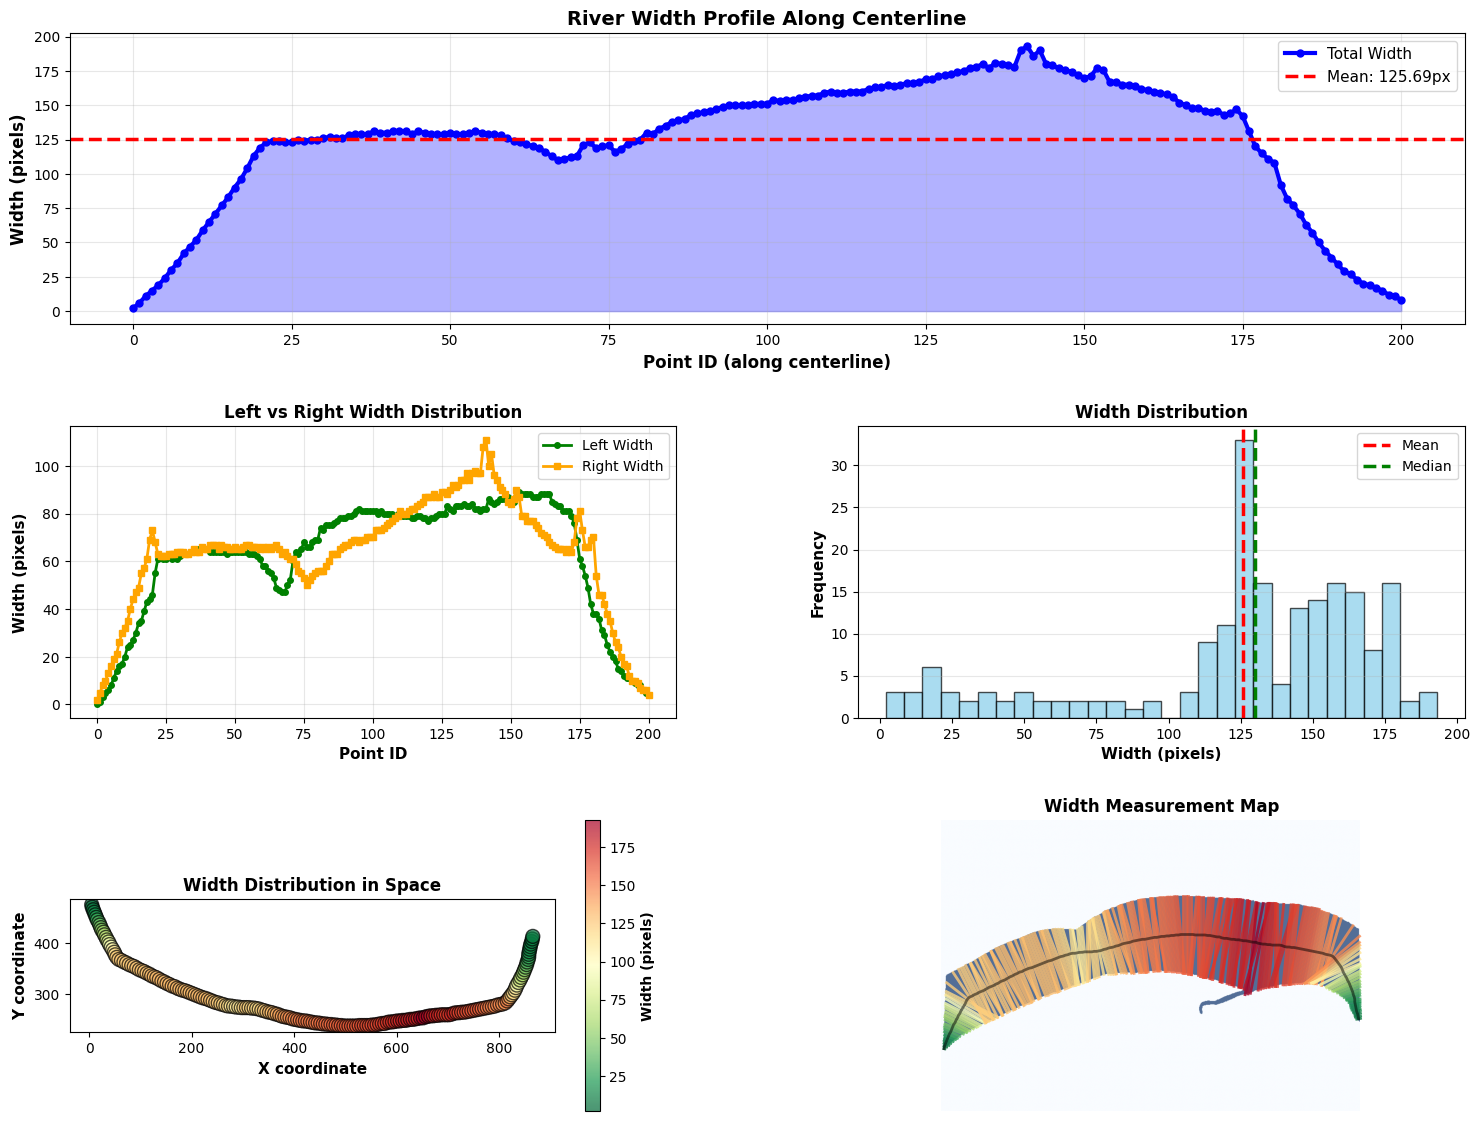

In [57]:
print("\n" + "="*70)
print("STEP 4: WIDTH PROFILE ANALYSIS")
print("="*70)

def plot_detailed_width_profile(df_widths, binary_map, x_centerline, y_centerline):
    """Plot detailed width analysis."""

    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

    # Plot 1: Width profile with left/right breakdown
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_widths['point_id'], df_widths['total_width_pixels'],
            'b-', linewidth=3, marker='o', markersize=5, label='Total Width')
    ax1.fill_between(df_widths['point_id'], df_widths['total_width_pixels'],
                    alpha=0.3, color='blue')
    ax1.axhline(y=df_widths['total_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2.5,
               label=f"Mean: {df_widths['total_width_pixels'].mean():.2f}px")
    ax1.set_xlabel('Point ID (along centerline)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Width (pixels)', fontsize=12, fontweight='bold')
    ax1.set_title('River Width Profile Along Centerline', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11, loc='upper right')

    # Plot 2: Left vs Right width
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df_widths['point_id'], df_widths['width_left_pixels'],
            'g-', linewidth=2, marker='o', markersize=4, label='Left Width')
    ax2.plot(df_widths['point_id'], df_widths['width_right_pixels'],
            'orange', linewidth=2, marker='s', markersize=4, label='Right Width')
    ax2.set_xlabel('Point ID', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Width (pixels)', fontsize=11, fontweight='bold')
    ax2.set_title('Left vs Right Width Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)

    # Plot 3: Width distribution histogram
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(df_widths['total_width_pixels'], bins=30, edgecolor='black',
            color='skyblue', alpha=0.7)
    ax3.axvline(x=df_widths['total_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2.5, label='Mean')
    ax3.axvline(x=df_widths['total_width_pixels'].median(), color='g',
               linestyle='--', linewidth=2.5, label='Median')
    ax3.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('Width Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Spatial width distribution
    ax4 = fig.add_subplot(gs[2, 0])
    scatter = ax4.scatter(df_widths['centerline_x'], df_widths['centerline_y'],
                         c=df_widths['total_width_pixels'], cmap='RdYlGn_r',
                         s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax4.set_xlabel('X coordinate', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Y coordinate', fontsize=11, fontweight='bold')
    ax4.set_title('Width Distribution in Space', fontsize=12, fontweight='bold')
    ax4.set_aspect('equal')
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Width (pixels)', fontsize=10, fontweight='bold')

    # Plot 5: Map with width lines
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.imshow(binary_map, cmap='Blues', alpha=0.7)

    # Plot width lines colored by width
    colors = plt.cm.RdYlGn_r(
        (df_widths['total_width_pixels'] - df_widths['total_width_pixels'].min()) /
        (df_widths['total_width_pixels'].max() - df_widths['total_width_pixels'].min())
    )

    for idx, row in df_widths.iterrows():
        ax5.plot([row['centerline_x'] - row['perp_dx'] * row['width_left_pixels'],
                 row['centerline_x'] + row['perp_dx'] * row['width_right_pixels']],
                [row['centerline_y'] - row['perp_dy'] * row['width_left_pixels'],
                 row['centerline_y'] + row['perp_dy'] * row['width_right_pixels']],
                color=colors[idx], linewidth=2, alpha=0.8)

    ax5.plot(x_centerline, y_centerline, 'k-', linewidth=2, alpha=0.5)
    ax5.set_title('Width Measurement Map', fontsize=12, fontweight='bold')
    ax5.axis('off')

    plt.tight_layout()
    plt.show()

# Plot detailed profile
print("Plotting detailed width profile...")
plot_detailed_width_profile(df_widths, binary_map, x_pruned_advanced, y_pruned_advanced)

In [65]:
print("\n" + "="*70)
print("STEP 5: EXPORTING RESULTS")
print("="*70)

# Export width measurements as CSV
print("Exporting width measurements...")
df_widths.to_csv('river_width_measurements.csv', index=False)
print("✓ Saved: river_width_measurements.csv")

# Export width lines as shapefile
print("Exporting perpendicular width lines...")
gdf_width_lines.to_file('perpendicular_width_lines.shp')
print("✓ Saved: perpendicular_width_lines.shp")

# Export centerline as shapefile
print("Exporting centerline...")
centerline_geom = LineString(list(zip(x_pruned_advanced, y_pruned_advanced)))
gdf_centerline = gpd.GeoDataFrame({'geometry': [centerline_geom]}, crs='EPSG:4326')
gdf_centerline.to_file('river_centerline.shp')
print("✓ Saved: river_centerline.shp")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total width measurements: {len(df_widths)}")
print(f"Mean width: {df_widths['total_width_pixels'].mean():.2f} pixels")
print(f"Max width: {df_widths['total_width_pixels'].max():.2f} pixels")
print(f"Min width: {df_widths['total_width_pixels'].min():.2f} pixels")
print(f"Std deviation: {df_widths['total_width_pixels'].std():.2f} pixels")

print("\nExported files:")
print("  1. river_width_measurements.csv - All width measurements")
print("  2. perpendicular_width_lines.shp - Width measurement lines")
print("  3. river_centerline.shp - River centerline")


STEP 5: EXPORTING RESULTS
Exporting width measurements...
✓ Saved: river_width_measurements.csv
Exporting perpendicular width lines...
✓ Saved: perpendicular_width_lines.shp
Exporting centerline...
✓ Saved: river_centerline.shp

SUMMARY
Total width measurements: 201
Mean width: 125.69 pixels
Max width: 193.00 pixels
Min width: 2.00 pixels
Std deviation: 46.32 pixels

Exported files:
  1. river_width_measurements.csv - All width measurements
  2. perpendicular_width_lines.shp - Width measurement lines
  3. river_centerline.shp - River centerline


/tmp/ipykernel_540/1279556664.py:12: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_width_lines.to_file('perpendicular_width_lines.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'width_pixels' to 'width_pixe'
  ogr_write(
